# Cytoscape CX2 export

CX2 is useful when a graph should be inspected in Cytoscape.
AnnNet can choose how hyperedges are projected for tools that
do not support them directly.


In [1]:
import annnet as an

an.info()


Version,v0.2.0
License,BSD-3-Clause
Authors,"Youssef Zerta ✉, Daniele Bottazzi ✉, Denes Turei ✉"
Repository,https://github.com/saezlab/annnet
Documentation,https://saezlab.github.io/annnet/reference/
Default graph backend,networkx
Default plot backend,graphviz
Graph backends,✓networkx✓igraph✗graph-tool✓pyg
Plot backends,✓graphviz✗pydot✓matplotlib
Tabular data backends,✓polars✓pandas✓pyarrow
I/O modules,✓annnet✓json/ndjson✓dataframes✓csv✓excel✓graphml/gexf✓sif✓cx2✓parquet✓zarr✗sbml✓scverse✓omnipath


## Build a graph with a hyperedge


In [2]:
G = an.AnnNet(directed=True)
G.add_vertices(['A', 'B', 'C', 'D', 'E'])
G.add_edges('A', 'B', edge_id='binary_edge', weight=1.0)
G.add_edges('A', 'B', edge_id='parallel_edge', weight=0.65)
G.add_edges('B', 'C', edge_id='complex_edge', directed=False, weight=0.8)
G.add_edges(src=['B', 'C'], tgt=['D', 'E'], edge_id='reaction', directed=True, weight=2.0)
G.attrs.set_vertex_attrs_bulk(
    {
        'A': {'label': 'ligand'},
        'B': {'label': 'enzyme'},
        'C': {'label': 'cofactor'},
        'D': {'label': 'product'},
        'E': {'label': 'byproduct'},
    }
)

G.views.edges().select(['edge_id', 'kind', 'source', 'target', 'head', 'tail'])


edge_id,kind,source,target,head,tail
str,str,str,str,list[str],list[str]
"""binary_edge""","""binary""","""A""","""B""",null,null
"""parallel_edge""","""binary""","""A""","""B""",null,null
"""complex_edge""","""binary""","""B""","""C""",null,null
"""reaction""","""hyper""","""B|C""","""D|E""","[""B"", ""C""]","[""D"", ""E""]"


## Preview the network

The CX2 file is for Cytoscape. For static documentation, a
Graphviz preview gives a lightweight embedded view of the same
topology.


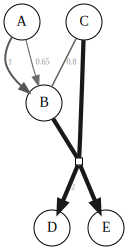

In [3]:
from annnet.utils import plotting

plotting.plot(G, backend='graphviz', show_edge_labels=True)


## Compare hyperedge export modes


In [4]:
for mode in ['skip', 'expand', 'reify']:
    cx2 = an.to_cx2(G, hyperedges=mode, export_name=f'annnet-{mode}')
    edge_aspect = next(item['edges'] for item in cx2 if 'edges' in item)
    node_aspect = next(item['nodes'] for item in cx2 if 'nodes' in item)
    print(mode, 'nodes:', len(node_aspect), 'edges:', len(edge_aspect))


skip nodes: 5 edges: 3
expand nodes: 5 edges: 7
reify nodes: 6 edges: 7


## Round-trip through the CX2 manifest


In [5]:
import json

cx2 = an.to_cx2(G, hyperedges='reify', export_name='annnet-reified')
restored = an.from_cx2(cx2)

print('restored shape:', restored.shape)
print('restored hyperedges:', sorted(restored.hyperedge_definitions))
print(json.dumps(cx2[:3], indent=2))


restored shape: (6, 5)
restored hyperedges: []
[
  {
    "CXVersion": "2.0",
    "hasFragments": false
  },
  {
    "metaData": [
      {
        "name": "attributeDeclarations",
        "elementCount": 1
      },
      {
        "name": "networkAttributes",
        "elementCount": 1
      },
      {
        "name": "nodes",
        "elementCount": 6
      },
      {
        "name": "edges",
        "elementCount": 7
      }
    ]
  },
  {
    "attributeDeclarations": [
      {
        "nodes": {
          "label": {
            "d": "string"
          },
          "name": {
            "d": "string"
          },
          "is_hyperedge": {
            "d": "boolean"
          },
          "eid": {
            "d": "string"
          },
          "tag": {
            "d": "string"
          },
          "reaction": {
            "d": "string"
          }
        },
        "edges": {
          "interaction": {
            "d": "string"
          },
          "weight": {
            "d"

`skip`, `expand`, and `reify` are explicit choices about what
Cytoscape should see. A true embedded Cytoscape.js widget would
need an additional browser asset; this notebook keeps the docs
static by showing the CX2 payload plus a Graphviz preview.
